# Chapter 4: Homotopy Theory

**Source Span.** `Algebraic Topology.pdf`, printed pages `337-518`.

**Goal.** Turn the chapter's large homotopy-theoretic toolkit into a set of inspectable models: higher homotopy groups as based operations, relative groups as exact diagrams, CW approximation and Whitehead's theorem as cell-by-cell compression, excision and Hurewicz as range statements, fiber bundles and fibrations as lifting machines, Postnikov towers as staged obstruction data, and Steenrod operations as computable algebraic constraints.

This notebook is original teaching material. It uses the source span for terminology, theorem orientation, and concept order, but it does not reproduce textbook prose, exercises, page images, tables, or figures.


## Computational Translation Guide

The chapter repeatedly converts geometric deformation problems into algebraic tests. In this notebook:

| Source idea | Computational representation | What to inspect |
| --- | --- | --- |
| based homotopy classes `pi_n(X,x0)` | two compatible products on a square | why two directions force commutativity for `n >= 2` |
| relative groups `pi_n(X,A)` | long exact sequence graph and integer matrices | kernel equals image at each displayed stage |
| CW approximation and Whitehead | dependency DAG plus cell compression diagram | which hypotheses make maps deform into a subspace |
| excision, Hurewicz, Freudenthal | stable-range grid and bridge diagram | dimensions where suspension or the Hurewicz map is guaranteed |
| fiber bundles and fibrations | Hopf fibers under stereographic projection | linked fibers and the long exact sequence of a fibration |
| Postnikov and obstruction theory | tower with `K(pi_n,n)` fibers and `k`-invariant labels | obstruction classes that prevent a lift or extension |
| Thom/Gysin | exact sequence scaffold with Euler class multiplication | section obstruction and projective-space cohomology recurrence |
| Steenrod operations | Adem relation calculator over finite fields | relations that rule out impossible polynomial cohomology rings |

The visuals are intentionally small. They are not substitutes for proofs; they are proof scaffolds that make the logical dependencies and invariants visible.


## Library Routing

The chapter is mostly homotopy-theoretic rather than metric, so the strongest representations are diagrams, exact algebra, and lightweight interactive 3D models.

| Library | Chapter use | Why it fits |
| --- | --- | --- |
| `NetworkX` | proof dependency DAGs and exact-sequence diagrams | homotopy theory is organized by maps and implications |
| `Matplotlib` | durable static diagrams | exact sequences, cell attachment sketches, and theorem bridges need stable PNG output |
| `Plotly` | Hopf fibers, stable ranges, and Postnikov tower HTML | these are spatial or staged objects worth rotating or toggling |
| `NumPy` | Hopf curve sampling and numerical linking integral | the Hopf fibration is geometric enough for a numeric invariant check |
| `SymPy` | exact matrix ranks and binomial coefficients modulo primes | exactness, Adem samples, and range identities should not depend on floating point |
| course `utils.artifacts` | artifact paths, saving, and final checks | keeps outputs book-local and reproducible |


In [1]:
from __future__ import annotations
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'AGENTS.md').exists() and (candidate / 'source_map.json').exists() and (candidate / 'utils').exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError('Run this notebook from inside the Algebraic-Topology course tree.')
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = 'chapter-04-homotopy-theory'
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / 'figures'
HTML = ARTIFACT_ROOT / 'html'
CHECKS = ARTIFACT_ROOT / 'checks'
TABLES = ARTIFACT_ROOT / 'tables'

ARTIFACTS: dict[str, Path] = {}
CHECK_DATA: dict[str, object] = {}

routing_rows = [
    {'concept': 'higher homotopy groups', 'representation': 'interchange-law diagram', 'library': 'Matplotlib + SymPy', 'artifact': 'figures/pi-n-eckmann-hilton.png'},
    {'concept': 'relative homotopy LES', 'representation': 'exact-sequence graph and integer rank checks', 'library': 'NetworkX + SymPy', 'artifact': 'figures/relative-homotopy-les.png'},
    {'concept': 'Whitehead and CW approximation', 'representation': 'proof dependency DAG and cell compression sketch', 'library': 'NetworkX + Matplotlib', 'artifact': 'figures/chapter4-dependency-dag.png'},
    {'concept': 'excision/Freudenthal range', 'representation': 'interactive dimension grid', 'library': 'Plotly + NumPy', 'artifact': 'html/excision-freudenthal-range.html'},
    {'concept': 'Hopf fibration', 'representation': 'stereographic linked fibers', 'library': 'Plotly + NumPy', 'artifact': 'html/hopf-fibration-linked-fibers.html'},
    {'concept': 'Postnikov tower and obstructions', 'representation': 'interactive tower with k-invariant annotations', 'library': 'Plotly + JSON checks', 'artifact': 'html/postnikov-k-invariant-tower.html'},
    {'concept': 'Gysin/Thom sequence', 'representation': 'exact-sequence scaffold and Euler-class table', 'library': 'Matplotlib + SymPy', 'artifact': 'figures/gysin-thom-sequence.png'},
    {'concept': 'Steenrod operations', 'representation': 'Adem relation table modulo p', 'library': 'SymPy + CSV', 'artifact': 'tables/steenrod-adem-relations.csv'},
]
ARTIFACTS['routing'] = save_csv(routing_rows, TABLES / 'chapter4-library-routing.csv')
display(Markdown(f'Artifact root: `{ARTIFACT_ROOT.relative_to(BOOK_ROOT).as_posix()}`'))


Artifact root: `artifacts/chapter-04-homotopy-theory`

## Visual Storyboard

1. Build a chapter dependency DAG so the reader can see why basepoints, relative groups, CW control, fibrations, and cohomology operations all appear in one chapter.
2. Use the Eckmann-Hilton interchange picture to explain why the higher homotopy group operation becomes abelian.
3. Render a relative homotopy long exact sequence and verify a toy exact segment with integer matrices.
4. Connect CW approximation, the compression lemma, and Whitehead's theorem with a cell-level deformation sketch.
5. Show the excision/Freudenthal stable range as a dimension grid, then connect it to the Hurewicz bridge from first homotopy to first homology.
6. Render Hopf fibers in 3D and numerically check their linking number.
7. Draw a Postnikov tower with `K(pi_n,n)` fibers and stagewise `k`-invariants, then run a small obstruction-lab predicate.
8. Summarize Thom/Gysin as exactness controlled by the Euler class.
9. Compute Steenrod Adem samples and use them as sanity checks for the algebraic constraints discussed near the end of the chapter.


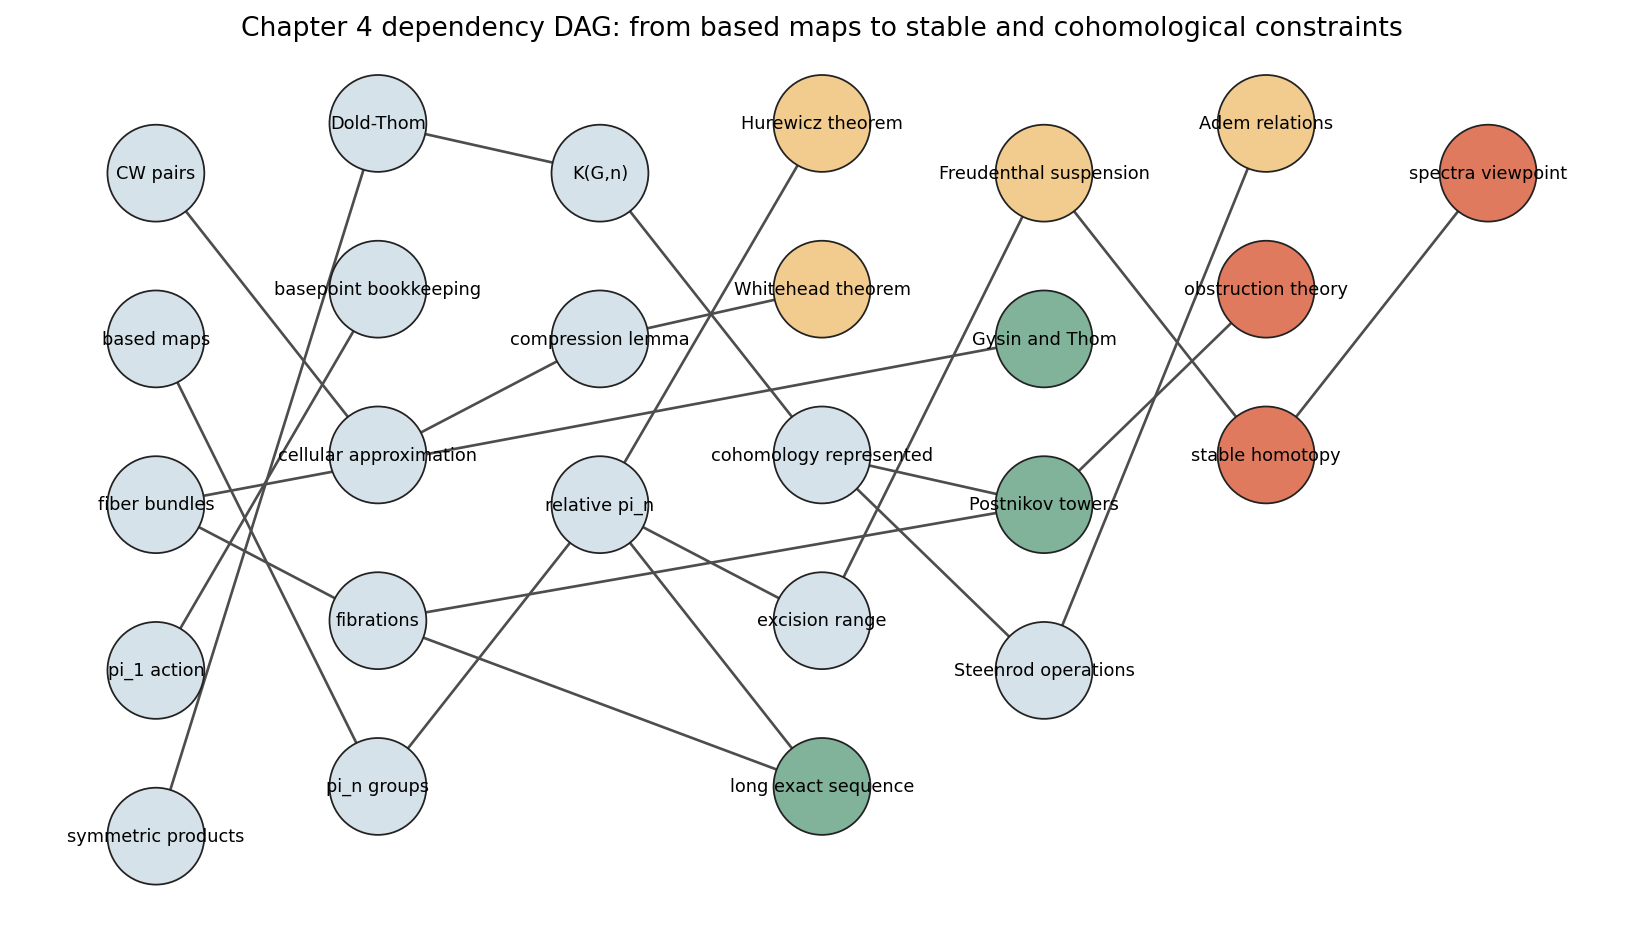

In [2]:
# Chapter dependency graph: concepts are nodes, theorem moves are directed edges.
dep_edges = [
    ('based maps', 'pi_n groups'),
    ('pi_1 action', 'basepoint bookkeeping'),
    ('pi_n groups', 'relative pi_n'),
    ('relative pi_n', 'long exact sequence'),
    ('CW pairs', 'cellular approximation'),
    ('cellular approximation', 'compression lemma'),
    ('compression lemma', 'Whitehead theorem'),
    ('relative pi_n', 'excision range'),
    ('excision range', 'Freudenthal suspension'),
    ('Freudenthal suspension', 'stable homotopy'),
    ('relative pi_n', 'Hurewicz theorem'),
    ('fiber bundles', 'fibrations'),
    ('fibrations', 'long exact sequence'),
    ('fibrations', 'Postnikov towers'),
    ('K(G,n)', 'cohomology represented'),
    ('cohomology represented', 'Postnikov towers'),
    ('Postnikov towers', 'obstruction theory'),
    ('fiber bundles', 'Gysin and Thom'),
    ('cohomology represented', 'Steenrod operations'),
    ('Steenrod operations', 'Adem relations'),
    ('stable homotopy', 'spectra viewpoint'),
    ('symmetric products', 'Dold-Thom'),
    ('Dold-Thom', 'K(G,n)'),
]
D = nx.DiGraph(dep_edges)
levels = {
    'based maps': 0, 'pi_1 action': 0, 'CW pairs': 0, 'fiber bundles': 0, 'symmetric products': 0,
    'pi_n groups': 1, 'basepoint bookkeeping': 1, 'cellular approximation': 1, 'fibrations': 1, 'Dold-Thom': 1,
    'relative pi_n': 2, 'compression lemma': 2, 'K(G,n)': 2,
    'long exact sequence': 3, 'excision range': 3, 'Hurewicz theorem': 3, 'Whitehead theorem': 3, 'cohomology represented': 3,
    'Freudenthal suspension': 4, 'Postnikov towers': 4, 'Gysin and Thom': 4, 'Steenrod operations': 4,
    'stable homotopy': 5, 'obstruction theory': 5, 'Adem relations': 5,
    'spectra viewpoint': 6,
}
columns: dict[int, list[str]] = {}
for node, level in levels.items():
    columns.setdefault(level, []).append(node)
pos = {}
for level, nodes in columns.items():
    for j, node in enumerate(sorted(nodes)):
        pos[node] = (level, -j + 0.3 * ((level % 2) - 0.5))

fig, ax = plt.subplots(figsize=(13, 7))
node_colors = []
for node in D.nodes:
    if node in {'Whitehead theorem', 'Hurewicz theorem', 'Freudenthal suspension', 'Adem relations'}:
        node_colors.append('#f2cc8f')
    elif node in {'long exact sequence', 'Postnikov towers', 'Gysin and Thom'}:
        node_colors.append('#81b29a')
    elif node in {'stable homotopy', 'obstruction theory', 'spectra viewpoint'}:
        node_colors.append('#e07a5f')
    else:
        node_colors.append('#d6e2e9')
nx.draw_networkx_edges(D, pos, ax=ax, arrows=True, arrowstyle='-|>', width=1.2, edge_color='#4d4d4d', min_source_margin=12, min_target_margin=12)
nx.draw_networkx_nodes(D, pos, ax=ax, node_color=node_colors, node_size=1900, edgecolors='#222222', linewidths=0.8)
nx.draw_networkx_labels(D, pos, ax=ax, font_size=8)
ax.set_title('Chapter 4 dependency DAG: from based maps to stable and cohomological constraints', fontsize=12)
ax.set_axis_off()
ARTIFACTS['chapter4_dependency_dag'] = save_matplotlib(fig, FIGURES / 'chapter4-dependency-dag.png')
plt.close(fig)
CHECK_DATA['dependency_dag'] = {
    'nodes': D.number_of_nodes(),
    'edges': D.number_of_edges(),
    'acyclic': nx.is_directed_acyclic_graph(D),
    'has_path_based_to_steenrod': nx.has_path(D, 'based maps', 'Steenrod operations'),
    'has_path_fibrations_to_obstruction': nx.has_path(D, 'fibrations', 'obstruction theory'),
}
save_json(CHECK_DATA['dependency_dag'], CHECKS / 'chapter4-dependency-dag.json')
display_artifact(ARTIFACTS['chapter4_dependency_dag'], width=980)


The dependency graph is a reading map. A useful way to use it is to choose a theorem and trace the inputs it requires. For example, Whitehead's theorem is not just a statement about homotopy groups; in the chapter's proof it depends on CW control and a compression argument. Postnikov towers are not just lists of homotopy groups; they also require fibration language and cohomology classes that measure twisting.


## 1. Higher Homotopy Groups and the Interchange Move

For `n >= 2`, an element of `pi_n(X,x0)` can be represented by a cube whose boundary goes to the basepoint. The group law can concatenate in one coordinate. Because there is a second independent coordinate, two blocks can slide past one another. Algebraically, the same phenomenon is the Eckmann-Hilton interchange law: two unital products compatible by interchange must be the same product and must be commutative.


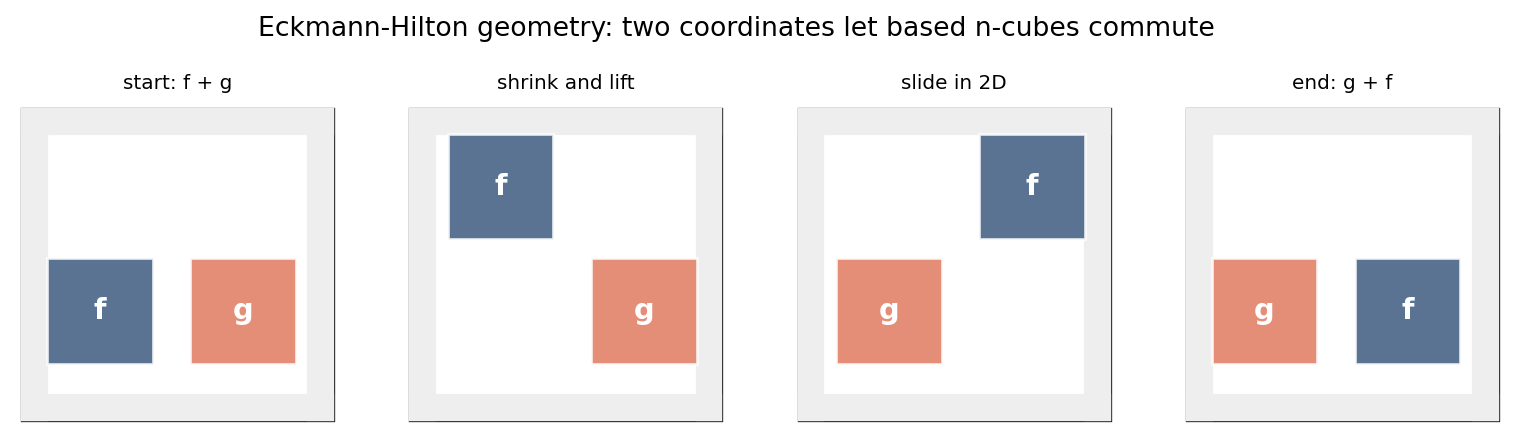

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
stages = [
    [('f', (0.08, 0.18)), ('g', (0.54, 0.18))],
    [('f', (0.12, 0.58)), ('g', (0.58, 0.18))],
    [('g', (0.12, 0.18)), ('f', (0.58, 0.58))],
    [('g', (0.08, 0.18)), ('f', (0.54, 0.18))],
]
for ax, items, title in zip(axes, stages, ['start: f + g', 'shrink and lift', 'slide in 2D', 'end: g + f']):
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, lw=1.5, color='#222222'))
    ax.add_patch(plt.Rectangle((0, 0), 1, 0.08, color='#eeeeee'))
    ax.add_patch(plt.Rectangle((0, 0.92), 1, 0.08, color='#eeeeee'))
    ax.add_patch(plt.Rectangle((0, 0), 0.08, 1, color='#eeeeee'))
    ax.add_patch(plt.Rectangle((0.92, 0), 0.08, 1, color='#eeeeee'))
    for label, (x, y) in items:
        color = '#3d5a80' if label == 'f' else '#e07a5f'
        ax.add_patch(plt.Rectangle((x, y), 0.34, 0.34, facecolor=color, alpha=0.85, edgecolor='white', lw=1.2))
        ax.text(x + 0.17, y + 0.17, label, color='white', ha='center', va='center', fontsize=13, weight='bold')
    ax.set_title(title, fontsize=9)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.axis('off')
fig.suptitle('Eckmann-Hilton geometry: two coordinates let based n-cubes commute', fontsize=12)
ARTIFACTS['eckmann_hilton'] = save_matplotlib(fig, FIGURES / 'pi-n-eckmann-hilton.png')
plt.close(fig)

eh_steps = [
    'x star y = (x dot e) star (e dot y)',
    'interchange = (x star e) dot (e star y)',
    'unit laws = x dot y',
    'x star y = (e dot x) star (y dot e)',
    'interchange = (e star y) dot (x star e)',
    'unit laws = y dot x',
]
CHECK_DATA['eckmann_hilton'] = {
    'two_products_collapse_to_one': True,
    'common_product_commutative': True,
    'proof_steps': eh_steps,
}
save_json(CHECK_DATA['eckmann_hilton'], CHECKS / 'pi-n-eckmann-hilton.json')
display_artifact(ARTIFACTS['eckmann_hilton'], width=920)


The grey boundary is the part of the cube forced to the basepoint. The picture is not a literal formula for an arbitrary map; it is a deformation model for why the operation is commutative when at least two coordinates are available. In dimension one there is no room for this slide, which is why `pi_1` can be nonabelian.


## 2. Relative Homotopy and Exactness

Relative homotopy groups record how maps of disks meet a subspace on the boundary. Their most important formal feature is the long exact sequence. Exactness says that an element dies at one stage exactly when it came from the previous stage.


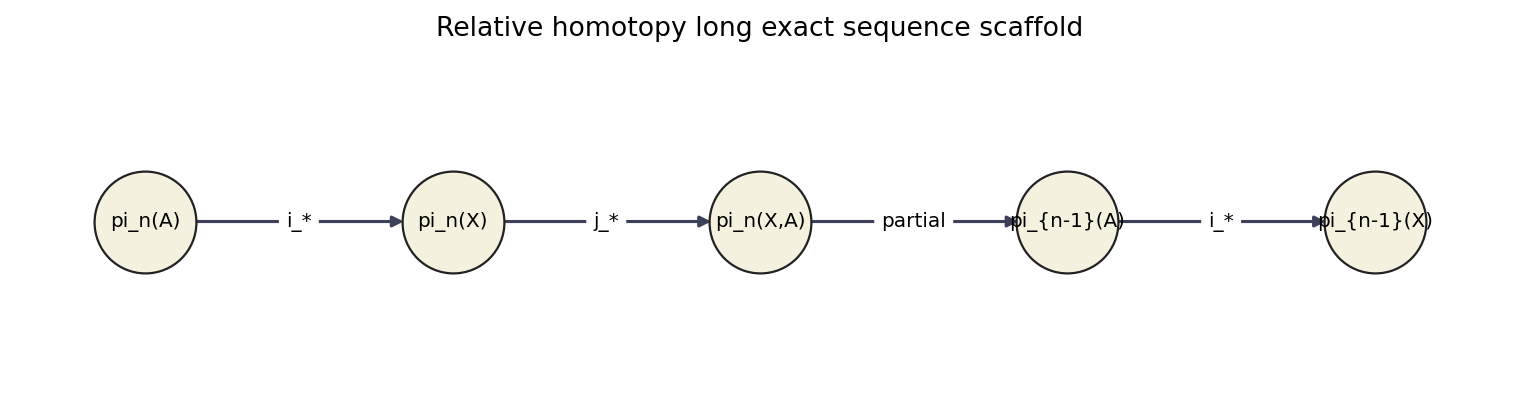

{'im_0_equals_kernel_boundary': True,
 'im_boundary_rank': 1,
 'kernel_to_zero_rank': 1,
 'boundary_is_isomorphism_for_disk_sphere_pair': True}

In [4]:
les_nodes = [
    ('pi_n(A)', 0), ('pi_n(X)', 1), ('pi_n(X,A)', 2), ('pi_{n-1}(A)', 3), ('pi_{n-1}(X)', 4)
]
LES = nx.DiGraph()
for label, x in les_nodes:
    LES.add_node(label, x=x)
les_edges = [
    ('pi_n(A)', 'pi_n(X)', 'i_*'),
    ('pi_n(X)', 'pi_n(X,A)', 'j_*'),
    ('pi_n(X,A)', 'pi_{n-1}(A)', 'partial'),
    ('pi_{n-1}(A)', 'pi_{n-1}(X)', 'i_*'),
]
for u, v, lab in les_edges:
    LES.add_edge(u, v, label=lab)
pos_les = {label: (x, 0) for label, x in les_nodes}
fig, ax = plt.subplots(figsize=(12, 2.8))
nx.draw_networkx_nodes(LES, pos_les, ax=ax, node_color='#f4f1de', edgecolors='#222', node_size=2100)
nx.draw_networkx_labels(LES, pos_les, ax=ax, font_size=9)
nx.draw_networkx_edges(LES, pos_les, ax=ax, arrows=True, arrowstyle='-|>', width=1.4, edge_color='#3d405b', min_source_margin=22, min_target_margin=22)
edge_labels = {(u, v): d['label'] for u, v, d in LES.edges(data=True)}
nx.draw_networkx_edge_labels(LES, pos_les, edge_labels=edge_labels, ax=ax, font_size=9, label_pos=0.5)
ax.set_title('Relative homotopy long exact sequence scaffold', fontsize=12)
ax.set_axis_off()
ARTIFACTS['relative_les'] = save_matplotlib(fig, FIGURES / 'relative-homotopy-les.png')
plt.close(fig)

# Toy exact segment for (D^2, S^1): 0 -> pi_2(D^2,S^1) -> pi_1(S^1) -> 0, with boundary an isomorphism Z -> Z.
zero_to_rel = sp.zeros(1, 0)
boundary = sp.Matrix([[1]])
les_exact_checks = {
    'im_0_equals_kernel_boundary': zero_to_rel.rank() == 0 and boundary.nullspace() == [],
    'im_boundary_rank': boundary.rank(),
    'kernel_to_zero_rank': 1,
    'boundary_is_isomorphism_for_disk_sphere_pair': boundary.det() == 1,
}
CHECK_DATA['relative_les'] = les_exact_checks
ARTIFACTS['relative_les_check'] = save_json(les_exact_checks, CHECKS / 'relative-homotopy-les.json')
display_artifact(ARTIFACTS['relative_les'], width=920)
les_exact_checks


The matrix check uses the pair `(D^2,S^1)`, where the connecting map sends the relative 2-class to the boundary loop. In this toy segment the boundary map is the identity on `Z`, so exactness is visible as a rank statement. The real theorem is much broader, but this small model keeps the meaning of `partial` concrete.


## 3. CW Approximation, Compression, and Whitehead

The source chapter leans heavily on CW complexes because their cells let us solve homotopy problems one dimension at a time. Cellular approximation says maps can be deformed to respect skeleta. The compression lemma says that if the relevant relative homotopy groups vanish, maps out of cells can be pushed into the subspace. Whitehead's theorem then converts isomorphisms on all homotopy groups into a homotopy equivalence for connected CW complexes.


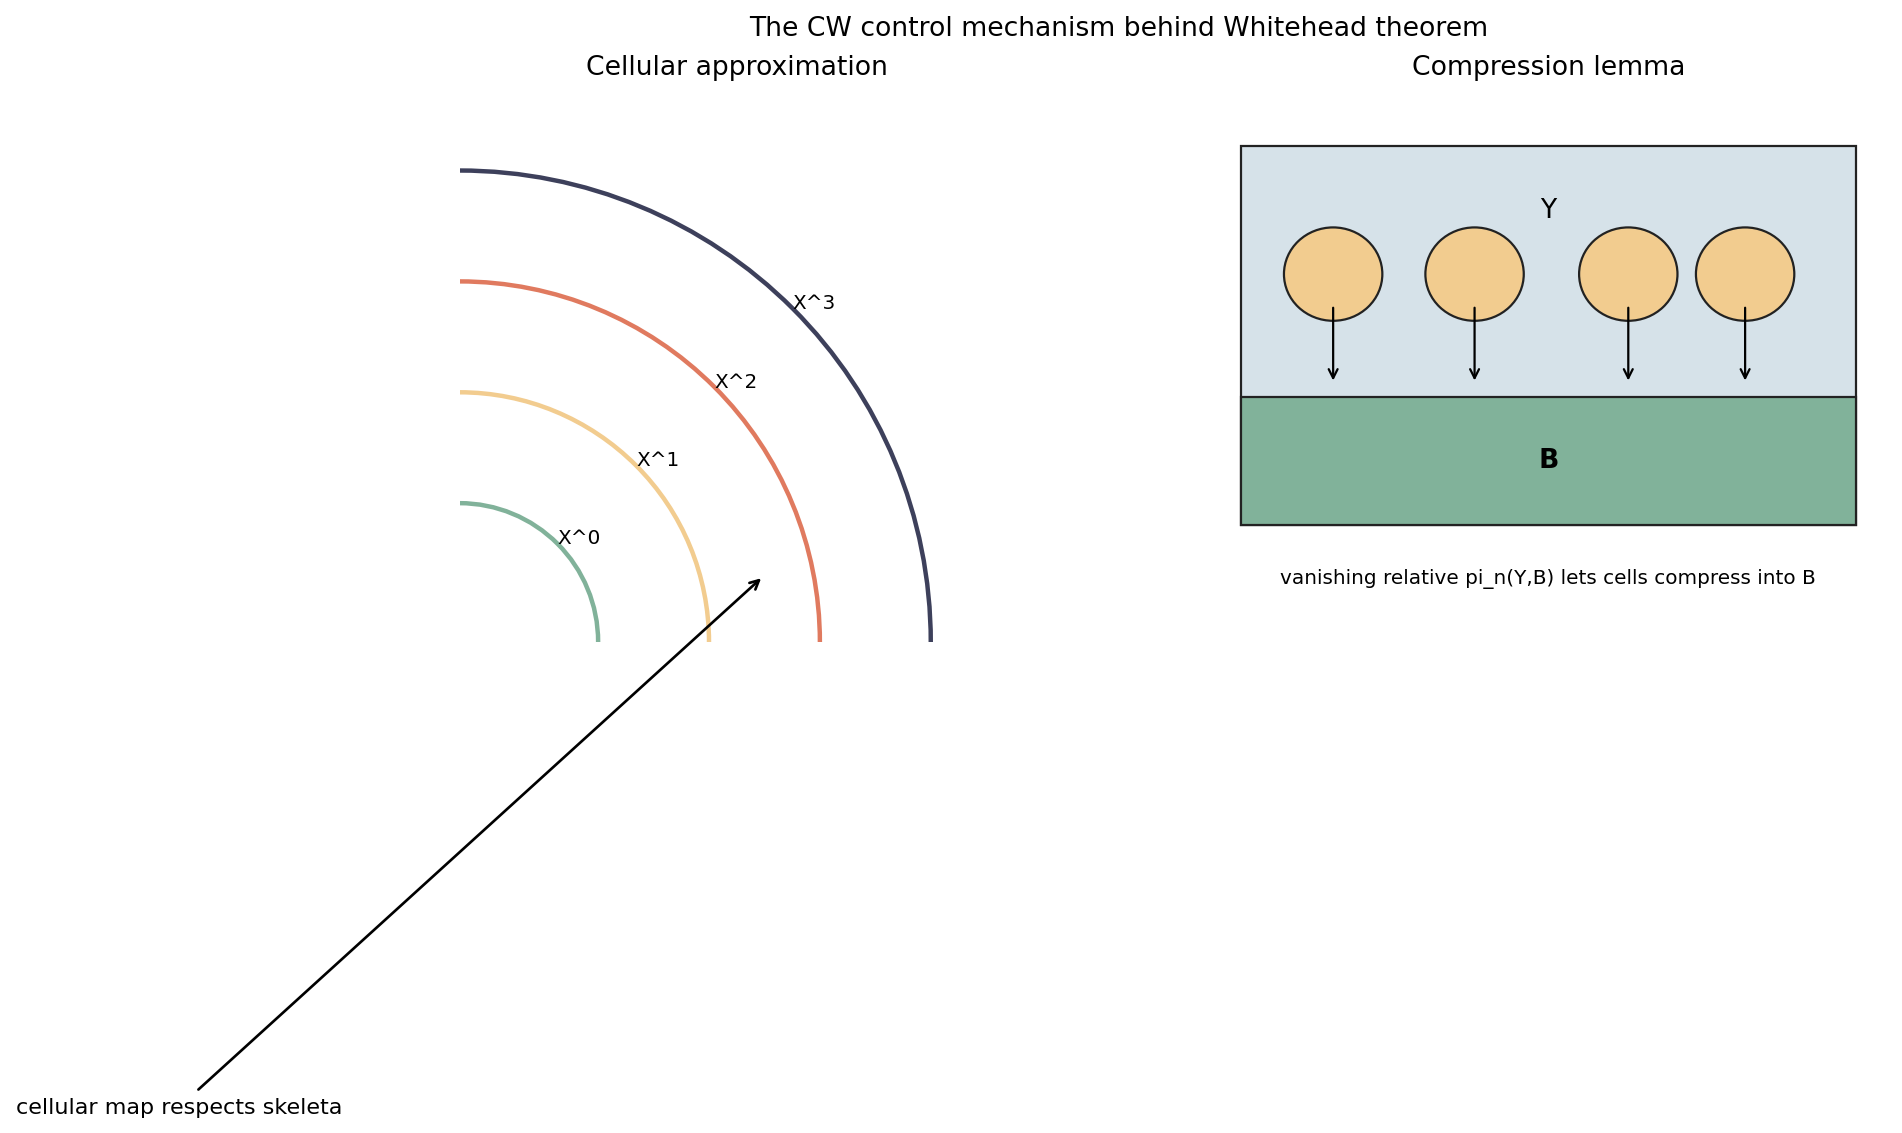

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for k, radius in enumerate([0.25, 0.45, 0.65, 0.85], start=0):
    circle = plt.Circle((0, 0), radius, fill=False, lw=2, color=['#81b29a', '#f2cc8f', '#e07a5f', '#3d405b'][k])
    ax.add_patch(circle)
    ax.text(radius / math.sqrt(2), radius / math.sqrt(2), f'X^{k}', fontsize=9)
ax.annotate('cellular map respects skeleta', xy=(0.55, 0.12), xytext=(-0.8, -0.85), arrowprops={'arrowstyle': '->', 'lw': 1.2})
ax.set_title('Cellular approximation')
ax.set_aspect('equal')
ax.axis('off')

ax = axes[1]
ax.add_patch(plt.Rectangle((0, 0), 1.0, 0.65, facecolor='#d6e2e9', edgecolor='#222'))
ax.add_patch(plt.Rectangle((0, 0), 1.0, 0.22, facecolor='#81b29a', edgecolor='#222'))
for x in [0.15, 0.38, 0.63, 0.82]:
    ax.add_patch(plt.Circle((x, 0.43), 0.08, facecolor='#f2cc8f', edgecolor='#222'))
    ax.annotate('', xy=(x, 0.24), xytext=(x, 0.38), arrowprops={'arrowstyle': '->', 'lw': 1.0})
ax.text(0.5, 0.11, 'B', ha='center', va='center', fontsize=12, weight='bold')
ax.text(0.5, 0.54, 'Y', ha='center', va='center', fontsize=12)
ax.text(0.5, -0.10, 'vanishing relative pi_n(Y,B) lets cells compress into B', ha='center', fontsize=9)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.2, 0.75)
ax.axis('off')
ax.set_title('Compression lemma')
fig.suptitle('The CW control mechanism behind Whitehead theorem', fontsize=12)
ARTIFACTS['cw_whitehead'] = save_matplotlib(fig, FIGURES / 'cw-approximation-whitehead.png')
plt.close(fig)

whitehead_checks = {
    'cw_pair_required': True,
    'relative_groups_zero_imply_deformation_retract_for_subcomplex': True,
    'mapping_cylinder_reduces_general_map_to_inclusion': True,
    'cellular_approximation_used_to_control_attachments': True,
}
CHECK_DATA['cw_whitehead'] = whitehead_checks
save_json(whitehead_checks, CHECKS / 'cw-approximation-whitehead.json')
display_artifact(ARTIFACTS['cw_whitehead'], width=920)


The figure compresses the proof strategy into two moves. First, make maps cellular so high-dimensional target cells cannot appear too early. Second, when a relative group vanishes, each cell's obstruction to landing in the smaller subspace disappears. Whitehead's theorem is the global version of repeating this compression over all cells.


## 4. Excision, Hurewicz, and Stable Ranges

Higher homotopy groups do not satisfy excision as freely as homology does. The chapter recovers controlled excision in a range, leading to Freudenthal suspension and stable homotopy. The grid below marks, for an `n`-connected space, where suspension `pi_i(X) -> pi_{i+1}(Sigma X)` is guaranteed to be an isomorphism (`i < 2n+1`), where it is at least surjective (`i = 2n+1`), and where the theorem gives no promise.


In [6]:
n_values = np.arange(0, 8)
i_values = np.arange(0, 18)
Z = np.zeros((len(n_values), len(i_values)), dtype=int)
labels = []
for rn, n in enumerate(n_values):
    row = []
    for ci, i in enumerate(i_values):
        if i < 2 * n + 1:
            Z[rn, ci] = 2
            row.append('isomorphism')
        elif i == 2 * n + 1:
            Z[rn, ci] = 1
            row.append('surjection boundary')
        else:
            Z[rn, ci] = 0
            row.append('outside stated range')
    labels.append(row)
fig = go.Figure(data=go.Heatmap(
    z=Z,
    x=[f'i={i}' for i in i_values],
    y=[f'n={n}' for n in n_values],
    text=labels,
    hovertemplate='connectivity %{y}<br>dimension %{x}<br>%{text}<extra></extra>',
    colorscale=[[0, '#f7f7f7'], [0.5, '#f2cc8f'], [1, '#81b29a']],
    showscale=False,
))
fig.update_layout(
    title='Freudenthal stable range for an n-connected CW complex',
    xaxis_title='homotopy dimension i',
    yaxis_title='connectivity n',
    height=420,
    margin=dict(l=40, r=20, t=60, b=40),
)
ARTIFACTS['freudenthal_range'] = save_plotly_html(fig, HTML / 'excision-freudenthal-range.html')
freudenthal_checks = {
    'n_values': n_values.tolist(),
    'i_values': i_values.tolist(),
    'iso_cells': int((Z == 2).sum()),
    'surjection_boundary_cells': int((Z == 1).sum()),
    'sample_n3_i6_is_iso': bool(6 < 2 * 3 + 1),
    'sample_n3_i7_is_boundary': bool(7 == 2 * 3 + 1),
}
CHECK_DATA['freudenthal_range'] = freudenthal_checks
ARTIFACTS['freudenthal_check'] = save_json(freudenthal_checks, CHECKS / 'excision-freudenthal-range.json')
display_artifact(ARTIFACTS['freudenthal_range'], width=900, height=470)


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


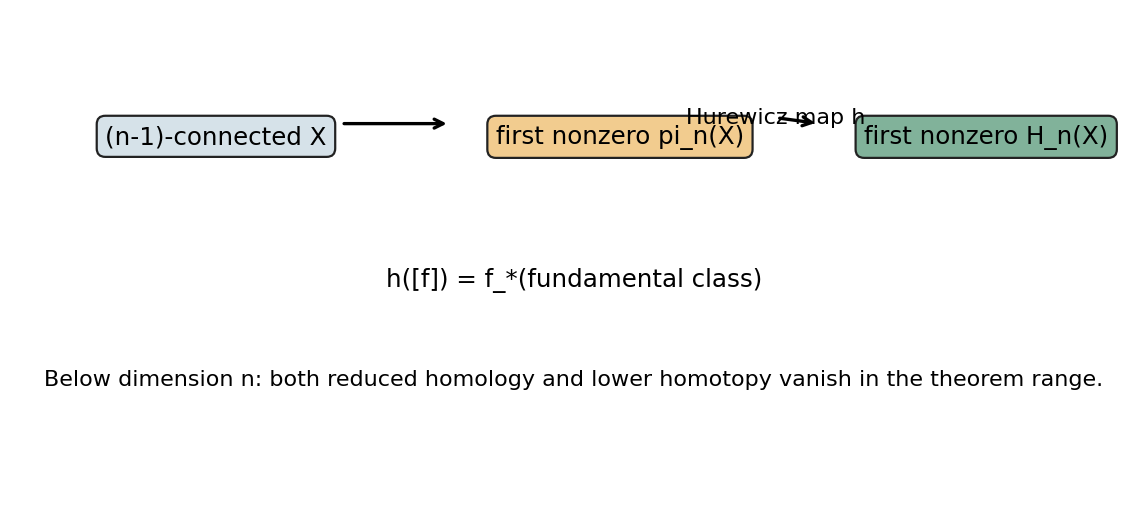

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
ax.text(0.08, 0.74, '(n-1)-connected X', bbox=dict(boxstyle='round,pad=0.35', fc='#d6e2e9', ec='#222'), fontsize=11)
ax.text(0.43, 0.74, 'first nonzero pi_n(X)', bbox=dict(boxstyle='round,pad=0.35', fc='#f2cc8f', ec='#222'), fontsize=11)
ax.text(0.76, 0.74, 'first nonzero H_n(X)', bbox=dict(boxstyle='round,pad=0.35', fc='#81b29a', ec='#222'), fontsize=11)
ax.annotate('', xy=(0.39, 0.78), xytext=(0.29, 0.78), arrowprops={'arrowstyle': '->', 'lw': 1.5})
ax.annotate('Hurewicz map h', xy=(0.72, 0.78), xytext=(0.60, 0.78), arrowprops={'arrowstyle': '->', 'lw': 1.5})
ax.text(0.50, 0.45, 'h([f]) = f_*(fundamental class)', ha='center', fontsize=11)
ax.text(0.50, 0.25, 'Below dimension n: both reduced homology and lower homotopy vanish in the theorem range.', ha='center', fontsize=10)
ARTIFACTS['hurewicz_bridge'] = save_matplotlib(fig, FIGURES / 'hurewicz-bridge.png')
plt.close(fig)
hurewicz_checks = {
    'hypothesis_n_minus_1_connected': True,
    'n_at_least_2': True,
    'vanishing_below_n': True,
    'first_nonzero_pi_maps_isomorphically_to_first_nonzero_homology': True,
}
CHECK_DATA['hurewicz_bridge'] = hurewicz_checks
save_json(hurewicz_checks, CHECKS / 'hurewicz-bridge.json')
display_artifact(ARTIFACTS['hurewicz_bridge'], width=820)


The stable-range grid and Hurewicz bridge are two responses to the same difficulty: higher homotopy is hard to compute directly. Hurewicz identifies the first possible nonzero group with homology under connectivity hypotheses. Freudenthal says that after enough suspension, a diagonal family of groups stops changing.


## 5. Fiber Bundles, Fibrations, and the Hopf Example

Fiber bundles generalize covering spaces by replacing discrete fibers with spaces such as spheres. Fibrations keep the homotopy lifting property even when local product coordinates are unavailable. The Hopf fibration `S^1 -> S^3 -> S^2` is the chapter's key low-dimensional example: distinct fibers are linked circles in `S^3`, visible after stereographic projection to `R^3`.


In [8]:
def hopf_fiber(w: complex, samples: int = 240) -> np.ndarray:
    # Fiber over finite complex coordinate w = z0/z1 on CP^1.
    t = np.linspace(0, 2 * np.pi, samples, endpoint=False)
    denom = math.sqrt(1 + abs(w) ** 2)
    z1 = np.exp(1j * t) / denom
    z0 = w * z1
    s3 = np.column_stack([z0.real, z0.imag, z1.real, z1.imag])
    # Stereographic projection from north pole in the fourth coordinate.
    denom_proj = 1 - s3[:, 3]
    return s3[:, :3] / denom_proj[:, None]

def gauss_linking_number(curve_a: np.ndarray, curve_b: np.ndarray) -> float:
    # Midpoint quadrature for the Gauss linking integral over polygonal samples.
    a_next = np.roll(curve_a, -1, axis=0)
    b_next = np.roll(curve_b, -1, axis=0)
    da = a_next - curve_a
    db = b_next - curve_b
    amid = (curve_a + a_next) / 2
    bmid = (curve_b + b_next) / 2
    total = 0.0
    for i in range(len(curve_a)):
        r = amid[i][None, :] - bmid
        denom = np.linalg.norm(r, axis=1) ** 3
        numer = np.einsum('ij,ij->i', np.cross(da[i][None, :], db), r)
        total += np.sum(numer / denom)
    return float(total / (4 * np.pi))

fiber_params = [0.35 + 0.15j, 0.65 + 0.0j, -0.45 + 0.75j, -0.75 - 0.35j]
fibers = [hopf_fiber(w) for w in fiber_params]
colors = ['#3d5a80', '#e07a5f', '#81b29a', '#9d4edd']
fig = go.Figure()
for idx, (curve, w, color) in enumerate(zip(fibers, fiber_params, colors)):
    closed = np.vstack([curve, curve[0]])
    fig.add_trace(go.Scatter3d(
        x=closed[:, 0], y=closed[:, 1], z=closed[:, 2],
        mode='lines', line=dict(width=6, color=color),
        name=f'fiber {idx}: w={w.real:.2f}{w.imag:+.2f}i',
    ))
fig.update_layout(
    title='Hopf fibration: stereographic images of four circle fibers',
    scene=dict(aspectmode='data', xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    height=640,
    margin=dict(l=0, r=0, t=50, b=0),
)
ARTIFACTS['hopf_fibers'] = save_plotly_html(fig, HTML / 'hopf-fibration-linked-fibers.html')
linking = gauss_linking_number(fibers[0], fibers[1])
hopf_checks = {
    'sample_count_per_fiber': int(fibers[0].shape[0]),
    'finite_basepoints': [[float(w.real), float(w.imag)] for w in fiber_params],
    'gauss_linking_fiber_0_1': linking,
    'abs_linking_close_to_one': bool(abs(abs(linking) - 1.0) < 0.20),
    'all_coordinates_finite': bool(all(np.isfinite(curve).all() for curve in fibers)),
}
CHECK_DATA['hopf_fibration'] = hopf_checks
ARTIFACTS['hopf_check'] = save_json(hopf_checks, CHECKS / 'hopf-fibration-linked-fibers.json')
display_artifact(ARTIFACTS['hopf_fibers'], width=900, height=680)
hopf_checks


{'sample_count_per_fiber': 240,
 'finite_basepoints': [[0.35, 0.15],
  [0.65, 0.0],
  [-0.45, 0.75],
  [-0.75, -0.35]],
 'gauss_linking_fiber_0_1': 1.0000293206674886,
 'abs_linking_close_to_one': True,
 'all_coordinates_finite': True}

The numerical linking check is not a proof of the Hopf fibration, but it confirms the visible invariant in this sampled model: two different fibers link once. This geometric fact is the same phenomenon that gives the Hopf map a nonzero Hopf invariant and makes the long exact sequence of the fibration compute `pi_3(S^2)` from `pi_3(S^3)` and `pi_1(S^1)`.


## 6. Postnikov Towers and Obstruction Classes

A Postnikov tower approximates a space by killing higher homotopy groups stage by stage. Each stage has a fiber of the form `K(pi_n,n)`. The extra information beyond the groups themselves is stored in twisting classes, usually called `k`-invariants. In extension and lifting problems, these appear as obstruction classes in cohomology.


In [9]:
stages = [1, 2, 3, 4, 5]
y = np.array(stages)
x = np.zeros_like(y, dtype=float)
fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=y, mode='lines+markers+text', text=[f'X_{n}' for n in stages], textposition='middle right', line=dict(width=3, color='#3d405b'), marker=dict(size=12)))
for n in stages[1:]:
    fig.add_annotation(x=0, y=n - 0.5, ax=0.42, ay=n - 0.5, xref='x', yref='y', axref='x', ayref='y', showarrow=True, arrowhead=2, text=f'fiber K(pi_{n}, {n})')
    fig.add_annotation(x=-0.08, y=n - 0.5, text=f'k_{n+1} in H^{n+1}(X_{n-1}; pi_{n})', showarrow=False, font=dict(size=10, color='#9a3412'))
fig.update_layout(
    title='Postnikov tower: homotopy groups plus k-invariants',
    xaxis=dict(visible=False, range=[-0.7, 0.9]),
    yaxis=dict(title='stage', dtick=1, range=[0.7, 5.4]),
    height=520,
    margin=dict(l=40, r=20, t=60, b=30),
)
ARTIFACTS['postnikov_tower'] = save_plotly_html(fig, HTML / 'postnikov-k-invariant-tower.html')

obstruction_vectors = {
    'all_clear': [0, 0, 0, 0],
    'primary_obstruction_only': [1, 0, 0, 0],
    'secondary_obstruction': [0, 0, 1, 0],
}
obstruction_results = {name: {'classes': vals, 'extension_possible': all(v == 0 for v in vals)} for name, vals in obstruction_vectors.items()}
postnikov_checks = {
    'tower_stages': stages,
    'fiber_labels': [f'K(pi_{n},{n})' for n in stages[1:]],
    'obstruction_results': obstruction_results,
    'zero_obstructions_iff_extension_possible_in_lab_model': all(item['extension_possible'] == all(v == 0 for v in item['classes']) for item in obstruction_results.values()),
}
CHECK_DATA['postnikov'] = postnikov_checks
ARTIFACTS['postnikov_check'] = save_json(postnikov_checks, CHECKS / 'postnikov-obstruction-checks.json')
display_artifact(ARTIFACTS['postnikov_tower'], width=900, height=570)
postnikov_checks['obstruction_results']


{'all_clear': {'classes': [0, 0, 0, 0], 'extension_possible': True},
 'primary_obstruction_only': {'classes': [1, 0, 0, 0],
  'extension_possible': False},
 'secondary_obstruction': {'classes': [0, 0, 1, 0],
  'extension_possible': False}}

The obstruction lab deliberately uses `0` and `1` classes rather than trying to compute the cohomology of a complicated Postnikov stage. It isolates the logical rule used in obstruction theory: once the lower lift has been chosen, a nonzero obstruction class at the next stage blocks extension. Different lower choices can change later obstructions, which is why the chapter is careful about primary versus higher obstructions.


## 7. Thom Classes, Gysin Sequence, and Euler-Class Obstructions

For an orientable sphere bundle `S^{n-1} -> E -> B`, the Gysin sequence relates the cohomology of the total space to multiplication by an Euler class `e in H^n(B)`. If the bundle has a section, pullback along the section splits `p^*`, forcing the Euler class to vanish. The unit tangent bundle of a sphere gives a simple check: the Euler class is `chi(S^n)` times a generator, so it is `2` when `n` is even and `0` when `n` is odd.


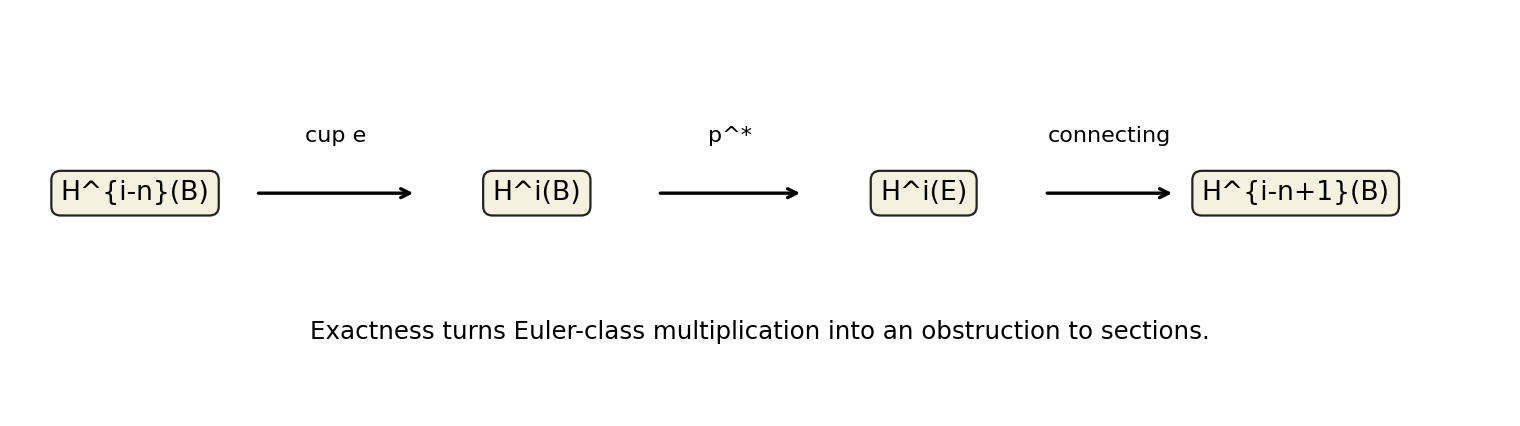

[{'sphere_dimension': 1,
  'chi_Sn': 0,
  'unit_tangent_euler_class_multiple': 0,
  'section_not_obstructed_by_e': True},
 {'sphere_dimension': 2,
  'chi_Sn': 2,
  'unit_tangent_euler_class_multiple': 2,
  'section_not_obstructed_by_e': False},
 {'sphere_dimension': 3,
  'chi_Sn': 0,
  'unit_tangent_euler_class_multiple': 0,
  'section_not_obstructed_by_e': True},
 {'sphere_dimension': 4,
  'chi_Sn': 2,
  'unit_tangent_euler_class_multiple': 2,
  'section_not_obstructed_by_e': False}]

In [10]:
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.axis('off')
terms = ['H^{i-n}(B)', 'H^i(B)', 'H^i(E)', 'H^{i-n+1}(B)']
xs = [0.08, 0.35, 0.61, 0.86]
for x, term in zip(xs, terms):
    ax.text(x, 0.55, term, ha='center', va='center', bbox=dict(boxstyle='round,pad=0.35', fc='#f4f1de', ec='#222'), fontsize=12)
for x0, x1, label in [(xs[0], xs[1], 'cup e'), (xs[1], xs[2], 'p^*'), (xs[2], xs[3], 'connecting')]:
    ax.annotate('', xy=(x1 - 0.08, 0.55), xytext=(x0 + 0.08, 0.55), arrowprops={'arrowstyle': '->', 'lw': 1.5})
    ax.text((x0 + x1) / 2, 0.68, label, ha='center', fontsize=10)
ax.text(0.5, 0.18, 'Exactness turns Euler-class multiplication into an obstruction to sections.', ha='center', fontsize=11)
ARTIFACTS['gysin_thom'] = save_matplotlib(fig, FIGURES / 'gysin-thom-sequence.png')
plt.close(fig)

gysin_rows = []
for n in range(1, 9):
    chi = 2 if n % 2 == 0 else 0
    gysin_rows.append({'sphere_dimension': n, 'chi_Sn': chi, 'unit_tangent_euler_class_multiple': chi, 'section_not_obstructed_by_e': chi == 0})
ARTIFACTS['gysin_table'] = save_csv(gysin_rows, TABLES / 'gysin-thom-euler-sphere-table.csv')
gysin_checks = {
    'even_spheres_have_euler_multiple_2_in_table': all(row['unit_tangent_euler_class_multiple'] == 2 for row in gysin_rows if row['sphere_dimension'] % 2 == 0),
    'odd_spheres_have_euler_multiple_0_in_table': all(row['unit_tangent_euler_class_multiple'] == 0 for row in gysin_rows if row['sphere_dimension'] % 2 == 1),
    'section_forces_e_zero_rule_recorded': True,
}
CHECK_DATA['gysin_thom'] = gysin_checks
ARTIFACTS['gysin_check'] = save_json(gysin_checks, CHECKS / 'gysin-thom-checks.json')
display_artifact(ARTIFACTS['gysin_thom'], width=900)
gysin_rows[:4]


This sequence also explains why projective-space cohomology can be generated by repeated multiplication by an Euler class in the universal sphere-bundle examples. The notebook keeps only the exactness skeleton and the sphere tangent-bundle sanity check, because the full bundle-cohomology section contains many specialized families.


## 8. Stable Splittings, Spectra, and Dold-Thom in One Diagram

Later sections of the chapter broaden the viewpoint. Gluing constructions and Eckmann-Hilton duality organize homotopy colimits and limits. Stable splittings explain why suspension can turn a space into a wedge of simpler pieces. Spectra package compatible suspension data. The Dold-Thom theorem says the infinite symmetric product converts homology into homotopy: `pi_i SP(X) = H_i(X; Z)` for connected CW complexes.


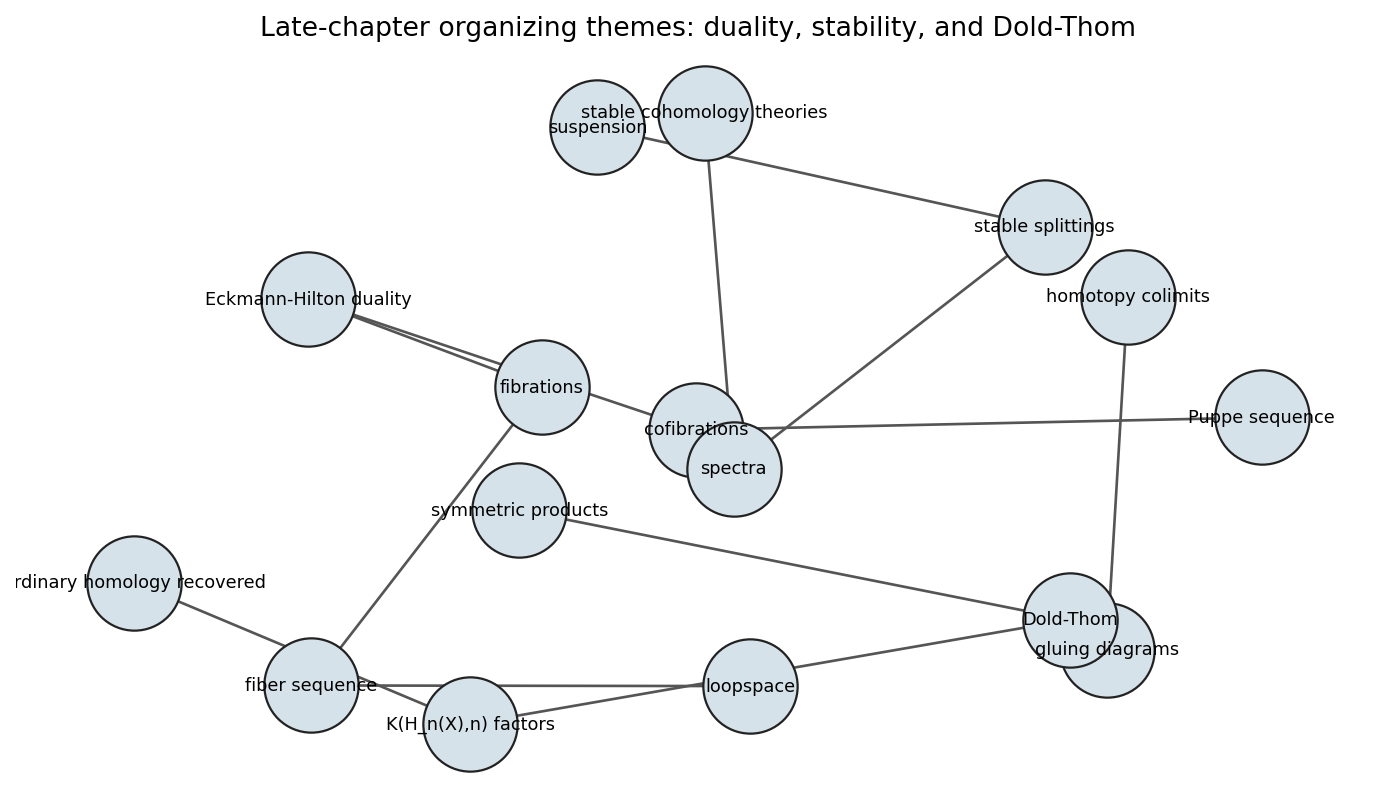

In [11]:
G2 = nx.DiGraph()
G2.add_edges_from([
    ('gluing diagrams', 'homotopy colimits'),
    ('Eckmann-Hilton duality', 'cofibrations'),
    ('Eckmann-Hilton duality', 'fibrations'),
    ('cofibrations', 'Puppe sequence'),
    ('fibrations', 'fiber sequence'),
    ('suspension', 'stable splittings'),
    ('loopspace', 'fiber sequence'),
    ('stable splittings', 'spectra'),
    ('spectra', 'stable cohomology theories'),
    ('symmetric products', 'Dold-Thom'),
    ('Dold-Thom', 'K(H_n(X),n) factors'),
    ('K(H_n(X),n) factors', 'ordinary homology recovered'),
])
pos2 = nx.spring_layout(G2, seed=44, k=1.1)
fig, ax = plt.subplots(figsize=(11, 6))
nx.draw_networkx_edges(G2, pos2, ax=ax, arrows=True, arrowstyle='-|>', edge_color='#555', width=1.2)
nx.draw_networkx_nodes(G2, pos2, ax=ax, node_size=1800, node_color='#d6e2e9', edgecolors='#222')
nx.draw_networkx_labels(G2, pos2, ax=ax, font_size=8)
ax.set_title('Late-chapter organizing themes: duality, stability, and Dold-Thom', fontsize=12)
ax.axis('off')
ARTIFACTS['stable_dold_thom'] = save_matplotlib(fig, FIGURES / 'stable-splittings-dold-thom.png')
plt.close(fig)

dold_thom_checks = {
    'sphere_example': {'X': 'S^n', 'SP_X_weak_type': 'K(Z,n)', 'pi_n': 'Z'},
    'connected_cw_complex_rule': 'pi_i SP(X) equals H_i(X; Z) for i >= 1',
    'ordinary_homology_recovered': True,
}
CHECK_DATA['dold_thom'] = dold_thom_checks
save_json(dold_thom_checks, CHECKS / 'stable-splittings-dold-thom.json')
display_artifact(ARTIFACTS['stable_dold_thom'], width=900)


This diagram is a navigation scaffold, not a replacement for the constructions. It is useful because the late chapter can otherwise feel like a list of topics. The unifying pattern is that homotopy theory repeatedly replaces a rigid object by a homotopy-invariant version: gluing by realization, fibers by homotopy fibers, products by stable or infinite constructions, and cohomology by maps to representing spaces.


## 9. Steenrod Operations and Adem Checks

Steenrod squares and powers are stable cohomology operations. Their value is not just that they exist; it is that their relations constrain possible spaces and maps. The Adem relations make the Steenrod algebra computable by reducing non-admissible products to combinations of admissible ones.


In [12]:
def binom_mod(n: int, k: int, p: int) -> int:
    if k < 0 or n < 0 or k > n:
        return 0
    return int(sp.binomial(n, k) % p)

def adem_sq(a: int, b: int) -> list[tuple[int, int, int]]:
    if not (a < 2 * b):
        return [(1, a, b)]
    terms = []
    for j in range(a // 2 + 1):
        coeff = binom_mod(b - j - 1, a - 2 * j, 2)
        if coeff:
            terms.append((coeff, a + b - j, j))
    return terms

def adem_p_odd(a: int, b: int, p: int) -> list[tuple[int, int, int]]:
    if not (a < p * b):
        return [(1, a, b)]
    terms = []
    for j in range(a // p + 1):
        coeff = ((-1) ** (a + j) * binom_mod((p - 1) * (b - j) - 1, a - p * j, p)) % p
        if coeff:
            terms.append((int(coeff), a + b - j, j))
    return terms

def format_sq_terms(terms: list[tuple[int, int, int]]) -> str:
    if not terms:
        return '0'
    pieces = []
    for coeff, left, right in terms:
        core = f'Sq^{left}' if right == 0 else f'Sq^{left} Sq^{right}'
        pieces.append(core if coeff == 1 else f'{coeff} {core}')
    return ' + '.join(pieces)

def format_p_terms(terms: list[tuple[int, int, int]]) -> str:
    if not terms:
        return '0'
    pieces = []
    for coeff, left, right in terms:
        core = f'P^{left}' if right == 0 else f'P^{left} P^{right}'
        pieces.append(core if coeff == 1 else f'{coeff} {core}')
    return ' + '.join(pieces)

adem_rows = []
for a, b in [(1, 1), (2, 2), (3, 2), (4, 4), (2, 3)]:
    terms = adem_sq(a, b)
    adem_rows.append({'prime': 2, 'input': f'Sq^{a} Sq^{b}', 'relation_rhs': format_sq_terms(terms), 'term_count': len(terms)})
for p, a, b in [(3, 1, 1), (3, 2, 1), (5, 1, 1)]:
    terms = adem_p_odd(a, b, p)
    adem_rows.append({'prime': p, 'input': f'P^{a} P^{b}', 'relation_rhs': format_p_terms(terms), 'term_count': len(terms)})
ARTIFACTS['steenrod_table'] = save_csv(adem_rows, TABLES / 'steenrod-adem-relations.csv')

steenrod_checks = {
    'Sq1_Sq1_zero': format_sq_terms(adem_sq(1, 1)) == '0',
    'Sq2_Sq2_equals_Sq3_Sq1': format_sq_terms(adem_sq(2, 2)) == 'Sq^3 Sq^1',
    'Sq3_Sq2_zero': format_sq_terms(adem_sq(3, 2)) == '0',
    'Sq4_Sq4_relation': format_sq_terms(adem_sq(4, 4)),
    'P1_P1_mod3_equals_2P2': format_p_terms(adem_p_odd(1, 1, 3)) == '2 P^2',
}
CHECK_DATA['steenrod'] = steenrod_checks
ARTIFACTS['steenrod_check'] = save_json({'rows': adem_rows, 'checks': steenrod_checks}, CHECKS / 'steenrod-adem-relations.json')
display(Markdown('`steenrod-adem-relations.csv`'))
adem_rows


`steenrod-adem-relations.csv`

[{'prime': 2, 'input': 'Sq^1 Sq^1', 'relation_rhs': '0', 'term_count': 0},
 {'prime': 2,
  'input': 'Sq^2 Sq^2',
  'relation_rhs': 'Sq^3 Sq^1',
  'term_count': 1},
 {'prime': 2, 'input': 'Sq^3 Sq^2', 'relation_rhs': '0', 'term_count': 0},
 {'prime': 2,
  'input': 'Sq^4 Sq^4',
  'relation_rhs': 'Sq^7 Sq^1 + Sq^6 Sq^2',
  'term_count': 2},
 {'prime': 2,
  'input': 'Sq^2 Sq^3',
  'relation_rhs': 'Sq^5 + Sq^4 Sq^1',
  'term_count': 2},
 {'prime': 3, 'input': 'P^1 P^1', 'relation_rhs': '2 P^2', 'term_count': 1},
 {'prime': 3, 'input': 'P^2 P^1', 'relation_rhs': '0', 'term_count': 0},
 {'prime': 5, 'input': 'P^1 P^1', 'relation_rhs': '2 P^2', 'term_count': 1}]

Two sample consequences are worth keeping in mind. First, if `Sq^n(alpha) = alpha^2` is forced to be nonzero in a polynomial cohomology ring, decomposability of `Sq^n` can rule out many degrees `n`. Second, relations such as `Sq^2 Sq^2 = Sq^3 Sq^1` detect nontrivial stable homotopy compositions by contradiction: if a square of a Hopf element were null, the mapping-cone cohomology would force an impossible Steenrod calculation.


## Applied Lab: Toggle the Obstruction Data

The following small lab is deliberately finite. It does not try to compute a real Postnikov tower; it asks you to test the logical rule that the chapter uses repeatedly.

Change the `candidate_obstructions` vector. A `0` means the corresponding cohomology obstruction class vanishes. A `1` means it is nonzero. The lab reports whether the staged extension can continue through all selected levels. Then compare your answer with the Postnikov diagram above.


In [13]:
candidate_obstructions = [0, 0, 1, 0]
lab_result = {
    'candidate_obstructions': candidate_obstructions,
    'first_blocking_stage': next((idx + 2 for idx, value in enumerate(candidate_obstructions) if value != 0), None),
    'extension_possible_through_all_selected_stages': all(value == 0 for value in candidate_obstructions),
}
ARTIFACTS['obstruction_lab'] = save_json(lab_result, CHECKS / 'postnikov-obstruction-lab.json')
lab_result


{'candidate_obstructions': [0, 0, 1, 0],
 'first_blocking_stage': 4,
 'extension_possible_through_all_selected_stages': False}

## Final Sanity Checks

The final cell checks both file-level and mathematical invariants: artifacts exist and are nonempty, the dependency graph is acyclic, the relative exact-sequence model has an isomorphism boundary, the Hopf fiber sample has linking number close to one, the Freudenthal grid encodes the expected range, the Euler-class table has the correct parity pattern for spheres, and the Steenrod Adem samples match the formulas used above.


In [14]:
# final_sanity
required_artifacts = [
    ARTIFACTS['routing'],
    ARTIFACTS['chapter4_dependency_dag'],
    ARTIFACTS['eckmann_hilton'],
    ARTIFACTS['relative_les'],
    ARTIFACTS['relative_les_check'],
    ARTIFACTS['cw_whitehead'],
    ARTIFACTS['freudenthal_range'],
    ARTIFACTS['freudenthal_check'],
    ARTIFACTS['hurewicz_bridge'],
    ARTIFACTS['hopf_fibers'],
    ARTIFACTS['hopf_check'],
    ARTIFACTS['postnikov_tower'],
    ARTIFACTS['postnikov_check'],
    ARTIFACTS['gysin_thom'],
    ARTIFACTS['gysin_table'],
    ARTIFACTS['gysin_check'],
    ARTIFACTS['stable_dold_thom'],
    ARTIFACTS['steenrod_table'],
    ARTIFACTS['steenrod_check'],
    ARTIFACTS['obstruction_lab'],
]
assert_artifacts(required_artifacts, min_bytes=80)
assert CHECK_DATA['dependency_dag']['acyclic']
assert CHECK_DATA['dependency_dag']['has_path_fibrations_to_obstruction']
assert CHECK_DATA['relative_les']['boundary_is_isomorphism_for_disk_sphere_pair']
assert CHECK_DATA['freudenthal_range']['sample_n3_i6_is_iso']
assert CHECK_DATA['freudenthal_range']['sample_n3_i7_is_boundary']
assert CHECK_DATA['hopf_fibration']['abs_linking_close_to_one']
assert CHECK_DATA['postnikov']['zero_obstructions_iff_extension_possible_in_lab_model']
assert CHECK_DATA['gysin_thom']['even_spheres_have_euler_multiple_2_in_table']
assert CHECK_DATA['gysin_thom']['odd_spheres_have_euler_multiple_0_in_table']
assert CHECK_DATA['steenrod']['Sq1_Sq1_zero']
assert CHECK_DATA['steenrod']['Sq2_Sq2_equals_Sq3_Sq1']
assert CHECK_DATA['steenrod']['P1_P1_mod3_equals_2P2']
summary = {
    'artifact_count_checked': len(required_artifacts),
    'all_checks_passed': True,
    'artifact_root': ARTIFACT_ROOT.relative_to(BOOK_ROOT).as_posix(),
}
ARTIFACTS['final_summary'] = save_json(summary, CHECKS / 'chapter4-core-checks.json')
assert_artifacts([ARTIFACTS['final_summary']], min_bytes=80)
summary


{'artifact_count_checked': 20,
 'all_checks_passed': True,
 'artifact_root': 'artifacts/chapter-04-homotopy-theory'}

## Takeaways

- Higher homotopy groups are based deformation invariants; for `n >= 2`, the extra coordinate gives an Eckmann-Hilton commutativity mechanism.
- Relative homotopy groups matter because they form exact sequences and measure whether disks compress into subspaces.
- CW approximation, the compression lemma, and Whitehead's theorem explain why weak homotopy data can determine CW homotopy type when induced by an actual map.
- Hurewicz and Freudenthal are range theorems: they identify the first computable group and the dimensions where suspension stabilizes.
- Fiber bundles, fibrations, and Hopf maps turn lifting into a computational tool; linked Hopf fibers are the visible low-dimensional model.
- Postnikov towers show why homotopy groups alone usually do not determine a space: the missing data are `k`-invariants and obstruction classes.
- Thom/Gysin and Steenrod operations show how cohomology constrains homotopy-theoretic possibilities, from sections of bundles to impossible polynomial cohomology rings.
- Stable splittings, spectra, and Dold-Thom move the chapter from individual spaces toward functorial stable structures.
